# Using a CNN for multiclass classification with the CIFAR-10 dataset

This notebook will demonstrate the use of a basic CNN for multiclass classification with the CIFAR-10 dataset. This dataset consists of 60000 colour images of dimension 32 x 32 pixels split equally into 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck.

In [1]:
import torch
import random
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

To start let's view some examples of the images we are working with.

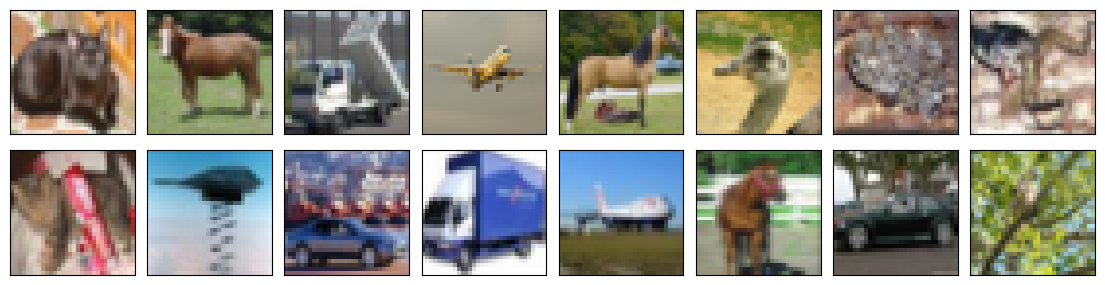

In [2]:
example_images = datasets.CIFAR10(root="./data", train=True, download=True)
ex_ims = [example_images[i][0] for i in random.sample(range(len(example_images)), 16)]

fig, axs = plt.subplots(nrows=2, ncols=8, figsize=(14, 14))
axs_flat = axs.flatten()
for i in range(16):
    ax = axs_flat[i]
    im = ax.imshow(ex_ims[i])  
    ax.set_xticks([])  
    ax.set_yticks([])
    
fig.subplots_adjust(hspace=-0.85, wspace=0.1)
plt.show()

Now we will import the data and apply transforms. To maximise performance, the training images will be scaled between 0 and 1 and then normalised. Some of the images will also undergo augmentation. The means and standard deviations were calculated from the training images beforehand. These values will also be utilised to normalise the test images after scaling. Finally, the training images are used to create training and validation sets.

In [3]:
# set the random seeds for the notebook
random.seed(11); np.random.seed(6); torch.manual_seed(42)
# previously calculated means and standard deviations for the training set
train_means = [0.4914010465145111, 0.4821591377258301, 0.44653117656707764]
train_stds = [0.2470322549343109, 0.24348513782024384, 0.26158785820007324]
# transform for scaling, augmenting and normalising the training data
train_transform = v2.Compose([v2.ToImage(), v2.RandomCrop(32, padding=4),v2.ToDtype(torch.float32, scale=True), 
                              v2.RandomHorizontalFlip(p=0.5),v2.Normalize(mean=train_means, std=train_stds)])
# transform for scaling and normalising the test data with the training data means and standard deviations
test_transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True), v2.Normalize(mean=train_means, std=train_stds)])
full_train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_size = 45000
val_size = 5000
train_set, valid_set = random_split(full_train_set, [train_size, val_size])

Below we define the CNN model. It consists of three convolutional blocks, each containing a convolutional layer, batch normalization, ReLU activation, and a max-pooling layer. The number of kernels increases in each layer from 32 to 64 to 128. This gives the model the capability to capture more complex and abstract combinations present in the images. Max-pooling layers reduce the dimensionality of the feature maps, which ultimately results in fewer neurons in the dense layers, helping to curb computational costs. After exiting the final convolutional block, the output is flattened and enters the first dense layer, followed by batch normalization and ReLU activation. Dropout is then employed; this strategy helps to prevent overfitting by injecting noise during training. By dropping random neurons during training steps, the network is forced to distribute its learning across different paths. Because the model trains on varied sub-networks, the full network during testing effectively approximates an ensemble average. A second dense layer and the ouput layer follow dropoout. Sometimes it is counterproductive to use dropout and batch normalisation together in the dense layers, but on this occasion performance is best with both included. 

In [4]:
class CNN(nn.Module):
    def __init__(self):

        super().__init__()

        self.layers = nn.Sequential(
            # Block 1
            # 3 x 32 x 32 -> 6 x 16 x 16
            # 32 - kernel_size + 2*padding + 1 = 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # 32 / 2 = 16
            nn.MaxPool2d(2),

            # Block 2
            # 6 x 16 x 16 -> 64 x 8 x 8
            # 16 - kernel_size + 2*padding + 1 = 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # 16 / 2 = 8
            nn.MaxPool2d(2),

            # Block 3
            # 64 x 8 x 8 -> 128 x 4 x 4
            # 64 - kernel_size + 2*padding + 1 = 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 8 / 2 = 4
            nn.MaxPool2d(2),

            # flatten
            nn.Flatten(start_dim=1),

            # first dense layer
            nn.Linear(128 * 4 * 4, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # dropout
            nn.Dropout(0.5),

            # second dense layer
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # output
            nn.Linear(32, 10)
        )


    def forward(self, x):

        return self.layers(x)

    
def train_valid(model, train_data, valid_data, epochs, learning_rate, weight_decay, batch_size=64):

    """Model training and validation. Stores loss and metric history."""

    optimiser = torch.optim.AdamW(params=model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_function = nn.CrossEntropyLoss()
    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False)

    model.train_epoch_losses = []
    model.valid_epoch_losses = []
    model.train_epoch_accs = []
    model.valid_epoch_accs = []
    model.train_epoch_bal_accs = []
    model.valid_epoch_bal_accs = []
    model.train_epoch_f1 = []
    model.valid_epoch_f1 = []

    for epoch in range(epochs):
        y_train_pred_list = []
        y_train_target_list = []
        y_valid_target_list = []
        y_valid_pred_list = []
        model.train()     
        train_batch_loss = 0
        valid_batch_loss = 0
        for batch_ids, (X_train_b, y_train_b) in enumerate(train_loader):
            optimiser.zero_grad()
            output = model(X_train_b.float())
            y_pred = output.argmax(dim=1)
            train_loss = loss_function(output, y_train_b.long())
            train_batch_loss += train_loss.item() * len(X_train_b)
            y_train_target_list.extend(y_train_b.detach().numpy().flatten())
            y_train_pred_list.extend(y_pred.detach().numpy().flatten())
            train_loss.backward()
            optimiser.step()

        train_epoch_conf_matrix = confusion_matrix(y_train_target_list, y_train_pred_list, labels=range(10))
        model.train_epoch_losses.append(train_batch_loss / len(train_data))
        model.train_epoch_accs.append(accuracy(train_epoch_conf_matrix))
        model.train_epoch_f1.append(macro_f1_score(train_epoch_conf_matrix))

        model.eval()
        with torch.no_grad():
            for batch_ids, (X_valid_b, y_valid_b) in enumerate(valid_loader):
                output = model(X_valid_b.float())
                y_pred = output.argmax(dim=1)
                valid_loss = loss_function(output, y_valid_b.long())
                valid_batch_loss += valid_loss.item() * len(X_valid_b)
                y_valid_target_list.extend(y_valid_b.detach().numpy().flatten())
                y_valid_pred_list.extend(y_pred.detach().numpy().flatten())

            valid_epoch_conf_matrix = confusion_matrix(y_valid_target_list, y_valid_pred_list, labels=range(10))
            model.valid_epoch_losses.append(valid_batch_loss / len(valid_data))
            model.valid_epoch_accs.append(accuracy(valid_epoch_conf_matrix))
            model.valid_epoch_f1.append(macro_f1_score(valid_epoch_conf_matrix))

        if (epoch + 1) % 10 == 0:
                    print("Epoch: {}, training loss: {:.3f}, validation loss: {:.3f}".format(epoch+1,
                                                                                           model.train_epoch_losses[-1], 
                                                                                           model.valid_epoch_losses[-1]))


def predict(model, test_data, batch_size=64):

    """Make predictions on the test set and calculate metrics."""

    test_loader = DataLoader(dataset=test_data, batch_size=batch_size)
    y_pred_list = []
    model.conf_mat = np.zeros((10, 10))
    model.eval()
    
    with torch.no_grad():
        for X_test, y_test in test_loader:
            output = model(X_test.float())
            y_pred = output.argmax(dim=1, keepdim=True)
            y_pred_list.extend(y_pred.tolist())
            conf_matrix = confusion_matrix(y_test, y_pred, labels=range(10))
            model.conf_mat += conf_matrix

    model.accuracy = accuracy(model.conf_mat)
    model.f1score = macro_f1_score(model.conf_mat)

    return y_pred_list


def conf_matrix_counts(matrix, label):

    tp = matrix[label, label].item()
    fp = (np.sum(matrix[:, label]) - tp).item()
    fn = (np.sum(matrix[label, :]) - tp).item()
    tn = (np.sum(matrix)).item() - tp - fp - fn

    return tp, fp, tn, fn


def accuracy(matrix):

    correct = np.diagonal(matrix).sum().item()
    all = np.sum(matrix).item()

    acc = correct / all

    return acc


def macro_av_precision(matrix):

    tot_pr = 0
    for i in range(len(matrix)):
        tp, fp, tn, fn = conf_matrix_counts(matrix, i)
        tot_pr += tp / (tp + fp)
    av_pr = tot_pr / len(matrix)

    return av_pr


def macro_av_recall(matrix):

    tot_re = 0
    for i in range(len(matrix)):
        tp, fp, tn, fn = conf_matrix_counts(matrix, i)
        tot_re += tp / (tp + fn)
    av_re = tot_re / len(matrix)

    return av_re


def macro_f1_score(matrix):

    f1_list = []
    for i in range(len(matrix)):
        tp, fp, tn, fn = conf_matrix_counts(matrix, i)
        class_pr = tp / (tp + fp)
        class_re = tp / (tp + fn)
        class_f1 = (2 * class_pr * class_re) / (class_pr + class_re)
        f1_list.append(class_f1)

    score = sum(f1_list) / len(f1_list)

    return score

It is time to train the CNN. We will evaluate its performance by comparing loss, accuracy and the F1 score for the training and validation sets.

Epoch: 10, training loss: 0.719, validation loss: 0.670
Epoch: 20, training loss: 0.603, validation loss: 0.612
Epoch: 30, training loss: 0.546, validation loss: 0.552
Epoch: 40, training loss: 0.516, validation loss: 0.527
Epoch: 50, training loss: 0.488, validation loss: 0.508


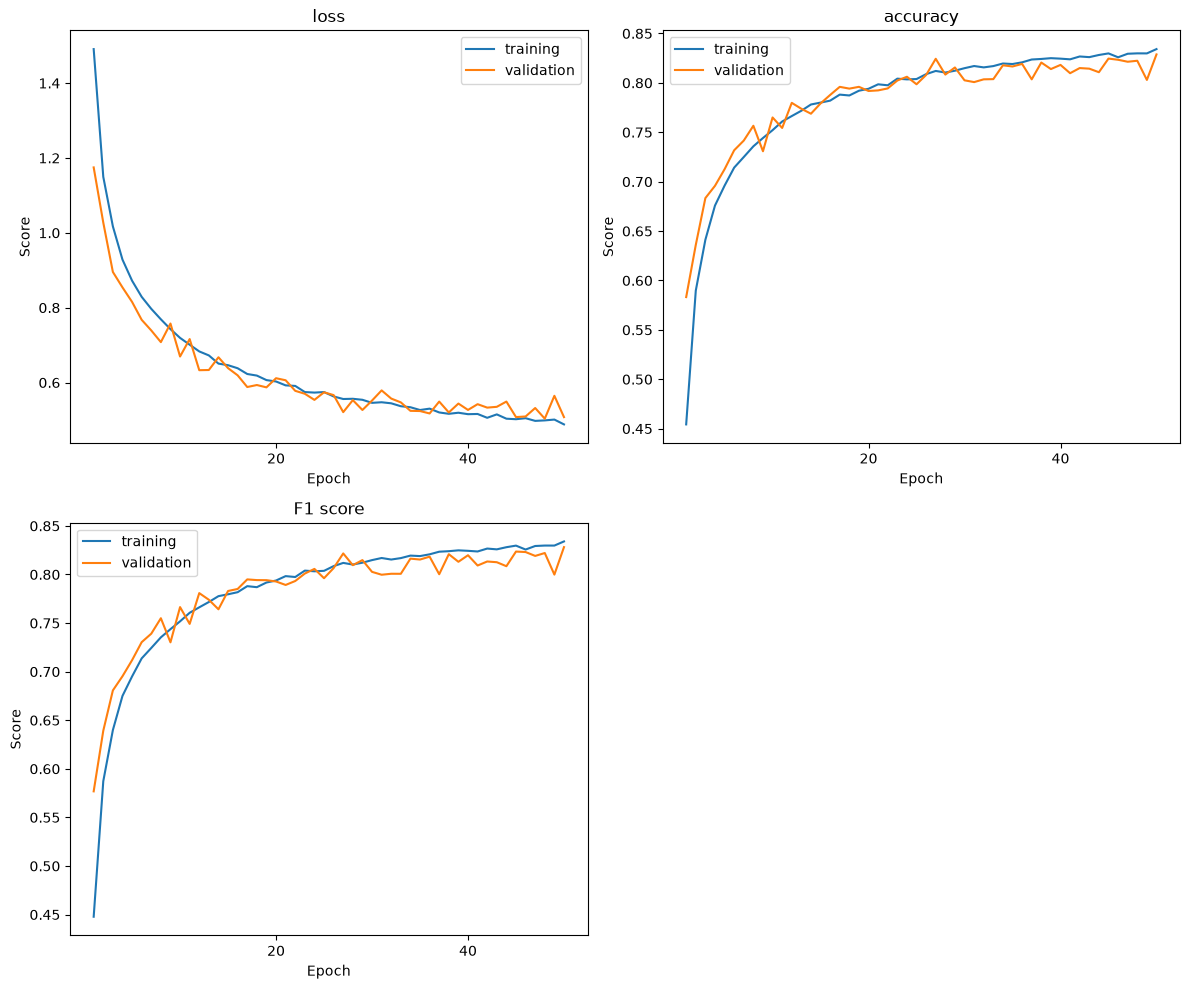

In [5]:
cnn = CNN()
train_valid(cnn, train_set, valid_set, 50, 0.003, 0.01)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()
metrics = [[cnn.train_epoch_losses, cnn.valid_epoch_losses], [cnn.train_epoch_accs, cnn.valid_epoch_accs],
           [cnn.train_epoch_f1, cnn.valid_epoch_f1]]
titles = ["loss", "accuracy", "F1 score"]
epochs = [i+1 for i in range(len(cnn.train_epoch_losses))]

for i in range(3):
    axs[i].plot(epochs, metrics[i][0], label="training")
    axs[i].plot(epochs, metrics[i][1], label="validation")
    axs[i].set_title(titles[i])
    axs[i].set_xticks(range(20, len(epochs)+1, 20))
    axs[i].set_xlabel("Epoch")
    axs[i].set_ylabel("Score")
    axs[i].legend()

axs[3].axis('off')

plt.tight_layout()
plt.show()

The model appears to be performing relatively well, achieving an accuracy of over 0.8 on the validation set and showing no obvious signs of overfitting. We could probably marginally improve performance by extending the number of epochs, but would not expect to see any significant gains.

In [6]:
print("Maximum validation accuracy: {:.5f}".format(max(cnn.valid_epoch_accs)))
print("Maximum validation F1 score: {:.5f}".format(max(cnn.valid_epoch_f1)))

Maximum validation accuracy: 0.82880
Maximum validation F1 score: 0.82816


In [7]:
y_pred = predict(cnn, test_set)
print("Test accuracy: {:.5f}, F1 score: {:.5f}".format(cnn.accuracy, cnn.f1score))


Test accuracy: 0.83740, F1 score: 0.83784


A test score of greater than 0.8 is good on this dataset for such a basic CNN without GPU access.